# CUR Decomposition

## Learning Objectives

1. **Motivate** CUR as an interpretable alternative to SVD
2. **Define** the column/row sampling procedure and importance-weighted probabilities
3. **Derive** the construction of $U = W^+$ (Moore-Penrose pseudo-inverse of the intersection)
4. **Prove** the error bound in terms of the best rank-$k$ approximation
5. **Implement** CUR from scratch and compare error to SVD


## Problem Statement

### Limitations of SVD

The SVD best rank-$k$ approximation $\hat{M} = U_k \Sigma_k V_k^\top$ is optimal in Frobenius norm, but:
- $U_k$ and $V_k^\top$ are dense, uninterpretable linear combinations
- For sparse $M$ (e.g. user-item rating matrices), $\hat{M}$ is dense
- The basis vectors don't correspond to actual rows/columns of $M$

### CUR Idea

Express $M \approx C U R$ where:
- $C$ = $k$ actual **columns** of $M$ (sampled with bias toward high-norm columns)
- $R$ = $k$ actual **rows** of $M$ (sampled similarly)
- $U$ = the Moore-Penrose pseudo-inverse of $W = M[\text{rows}, \text{cols}]$ (the intersection submatrix)

This gives an interpretable, often sparse approximation.

### Sampling Strategy

Column $j$ is sampled with probability proportional to its squared Frobenius norm:
$$p_j = \frac{\|\mathbf{M}_{:,j}\|_F^2}{\|M\|_F^2}$$

This biases toward important columns (those that explain more variance). After sampling, each column is rescaled by $1/\sqrt{k p_j}$ to make the estimator unbiased.


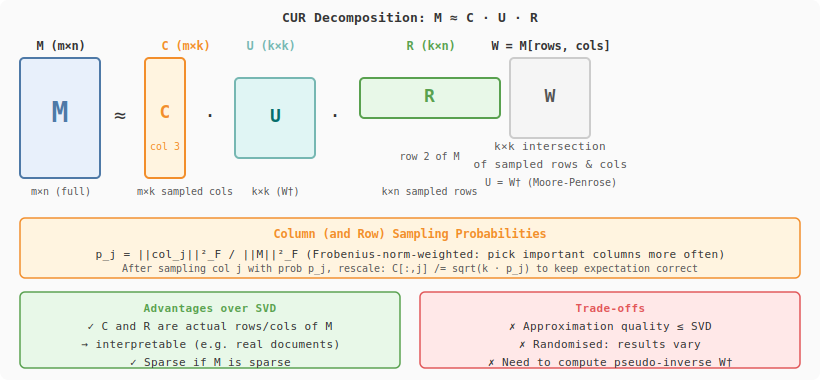

In [1]:
from IPython.display import SVG, display
svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="820" height="380" font-family="monospace" font-size="12">
  <rect width="820" height="380" fill="#fafafa" rx="8"/>
  <text x="410" y="22" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">CUR Decomposition:  M ≈ C · U · R</text>

  <!-- M matrix -->
  <text x="60" y="50" text-anchor="middle" fill="#333" font-size="12" font-weight="bold">M  (m×n)</text>
  <rect x="20" y="58" width="80" height="120" rx="4" fill="#e8f0fb" stroke="#4e79a7" stroke-width="2"/>
  <text x="60" y="122" text-anchor="middle" fill="#4e79a7" font-size="28" font-weight="bold">M</text>
  <text x="60" y="195" text-anchor="middle" fill="#555" font-size="10">m×n  (full)</text>

  <!-- equals sign -->
  <text x="120" y="122" text-anchor="middle" fill="#333" font-size="20">≈</text>

  <!-- C matrix (sampled columns) -->
  <text x="185" y="50" text-anchor="middle" fill="#f28e2b" font-size="12" font-weight="bold">C  (m×k)</text>
  <rect x="145" y="58" width="40" height="120" rx="4" fill="#fff4e0" stroke="#f28e2b" stroke-width="2"/>
  <text x="165" y="118" text-anchor="middle" fill="#f28e2b" font-size="18" font-weight="bold">C</text>
  <text x="165" y="150" text-anchor="middle" fill="#f28e2b" font-size="10">col 3</text>
  <text x="185" y="195" text-anchor="middle" fill="#555" font-size="10">m×k sampled cols</text>

  <!-- dot -->
  <text x="210" y="122" text-anchor="middle" fill="#333" font-size="20">·</text>

  <!-- U matrix (k×k pseudo-inverse of intersection) -->
  <text x="270" y="50" text-anchor="middle" fill="#76b7b2" font-size="12" font-weight="bold">U  (k×k)</text>
  <rect x="235" y="78" width="80" height="80" rx="4" fill="#e0f5f4" stroke="#76b7b2" stroke-width="2"/>
  <text x="275" y="122" text-anchor="middle" fill="#076d6a" font-size="18" font-weight="bold">U</text>
  <text x="275" y="195" text-anchor="middle" fill="#555" font-size="10">k×k  (W†)</text>

  <!-- dot -->
  <text x="335" y="122" text-anchor="middle" fill="#333" font-size="20">·</text>

  <!-- R matrix (sampled rows) -->
  <text x="430" y="50" text-anchor="middle" fill="#59a14f" font-size="12" font-weight="bold">R  (k×n)</text>
  <rect x="360" y="78" width="140" height="40" rx="4" fill="#e8f8e8" stroke="#59a14f" stroke-width="2"/>
  <text x="430" y="102" text-anchor="middle" fill="#59a14f" font-size="18" font-weight="bold">R</text>
  <text x="430" y="160" text-anchor="middle" fill="#555" font-size="10">row 2 of M</text>
  <text x="430" y="195" text-anchor="middle" fill="#555" font-size="10">k×n sampled rows</text>

  <!-- W (intersection) -->
  <text x="550" y="50" text-anchor="middle" fill="#333" font-size="12" font-weight="bold">W = M[rows, cols]</text>
  <rect x="510" y="58" width="80" height="80" rx="4" fill="#f5f5f5" stroke="#ccc" stroke-width="2"/>
  <text x="550" y="102" text-anchor="middle" fill="#555" font-size="18" font-weight="bold">W</text>
  <text x="550" y="150" text-anchor="middle" fill="#555" font-size="11">k×k  intersection</text>
  <text x="550" y="168" text-anchor="middle" fill="#555" font-size="11">of sampled rows &amp; cols</text>
  <text x="550" y="186" text-anchor="middle" fill="#555" font-size="10">U = W†  (Moore-Penrose)</text>

  <!-- sampling probability box -->
  <rect x="20" y="218" width="780" height="60" rx="5" fill="#fff4e0" stroke="#f28e2b" stroke-width="1.5"/>
  <text x="410" y="238" text-anchor="middle" fill="#f28e2b" font-size="12" font-weight="bold">Column (and Row) Sampling Probabilities</text>
  <text x="410" y="258" text-anchor="middle" fill="#333" font-size="11">p_j  =  ||col_j||²_F  /  ||M||²_F     (Frobenius-norm-weighted: pick important columns more often)</text>
  <text x="410" y="272" text-anchor="middle" fill="#555" font-size="10">After sampling col j with prob p_j, rescale: C[:,j] /= sqrt(k · p_j)  to keep expectation correct</text>

  <!-- advantages -->
  <rect x="20" y="292" width="380" height="76" rx="5" fill="#e8f8e8" stroke="#59a14f" stroke-width="1.5"/>
  <text x="210" y="312" text-anchor="middle" fill="#59a14f" font-size="11" font-weight="bold">Advantages over SVD</text>
  <text x="210" y="330" text-anchor="middle" fill="#333" font-size="11">✓ C and R are actual rows/cols of M</text>
  <text x="210" y="348" text-anchor="middle" fill="#333" font-size="11">  → interpretable (e.g. real documents)</text>
  <text x="210" y="366" text-anchor="middle" fill="#333" font-size="11">✓ Sparse if M is sparse</text>

  <rect x="420" y="292" width="380" height="76" rx="5" fill="#ffe8e8" stroke="#e15759" stroke-width="1.5"/>
  <text x="610" y="312" text-anchor="middle" fill="#e15759" font-size="11" font-weight="bold">Trade-offs</text>
  <text x="610" y="330" text-anchor="middle" fill="#333" font-size="11">✗ Approximation quality ≤ SVD</text>
  <text x="610" y="348" text-anchor="middle" fill="#333" font-size="11">✗ Randomised: results vary</text>
  <text x="610" y="366" text-anchor="middle" fill="#333" font-size="11">✗ Need to compute pseudo-inverse W†</text>
</svg>
'''
display(SVG(svg))


## Derivation

### Why This Sampling Probability?

Consider the random column matrix $C = \frac{1}{\sqrt{k p_j}} M_{:,j}$ when column $j$ is selected. Then:

$$E\left[\frac{1}{k} C C^\top\right] = \frac{1}{k} \sum_j p_j \cdot \frac{1}{k p_j^2} \cdot k p_j \cdot M_{:,j} M_{:,j}^\top \cdot k = M M^\top$$

So in expectation, the sampled columns approximate $M M^\top$ correctly.

### Construction of U

Let $W = M[\mathcal{R}, \mathcal{C}]$ be the $k \times k$ submatrix at the intersection of sampled rows $\mathcal{R}$ and sampled columns $\mathcal{C}$. Set:

$$U = W^+ = V_W \Sigma_W^+ U_W^\top$$

where $W = U_W \Sigma_W V_W^\top$ is the SVD of $W$, and $\Sigma_W^+$ replaces each nonzero singular value with its reciprocal.

### Error Bound

$$E[\|M - CUR\|_F^2] \leq \|M - M_k\|_F^2 + O\left(\frac{\|M\|_F^4 \|M_k\|_F}{k^{1/2}}\right)$$

where $M_k$ is the best rank-$k$ approximation (SVD). As $k$ grows, the CUR error approaches the SVD error.


## Algorithm Steps

1. Compute column norms $\|M_{:,j}\|_F^2$ and row norms $\|M_{i,:}\|_F^2$
2. Sample $k$ column indices $\mathcal{C}$ with replacement using $p_j \propto \|M_{:,j}\|_F^2$
3. Sample $k$ row indices $\mathcal{R}$ with replacement using $p_i \propto \|M_{i,:}\|_F^2$
4. Build $C = M_{:,\mathcal{C}}$ rescaled by $1/\sqrt{k p_j}$ per column
5. Build $R = M_{\mathcal{R},:}$ rescaled by $1/\sqrt{k p_i}$ per row
6. Build $W = M[\mathcal{R}, \mathcal{C}]$ (intersection submatrix)
7. Compute $U = W^+$ (Moore-Penrose pseudo-inverse via SVD of $W$)
8. Return $C, U, R$ and the selected indices


In [2]:
import numpy as np


def cur_decomposition(M, k, seed=42):
    """
    CUR Decomposition: M ≈ C @ U @ R

    Inputs
    ------
    M    : np.ndarray shape (m, n)
    k    : int — number of columns and rows to sample

    Output
    ------
    C    : np.ndarray shape (m, k) — rescaled sampled columns
    U    : np.ndarray shape (k, k) — pseudo-inverse of W (intersection)
    R    : np.ndarray shape (k, n) — rescaled sampled rows
    col_indices, row_indices : selected indices (for interpretability)
    """
    rng = np.random.default_rng(seed)
    m, n = M.shape

    # ── Sample columns with Frobenius-norm-weighted probabilities ─────────────
    col_norms_sq = np.sum(M ** 2, axis=0)
    M_frob_sq = col_norms_sq.sum()
    col_probs = col_norms_sq / M_frob_sq

    col_indices = rng.choice(n, size=k, replace=True, p=col_probs)

    # Rescale: each sampled column divided by sqrt(k * p_j)
    C = M[:, col_indices] / np.sqrt(k * col_probs[col_indices])

    # ── Sample rows with Frobenius-norm-weighted probabilities ────────────────
    row_norms_sq = np.sum(M ** 2, axis=1)
    row_probs = row_norms_sq / M_frob_sq

    row_indices = rng.choice(m, size=k, replace=True, p=row_probs)
    R = M[row_indices, :] / np.sqrt(k * row_probs[row_indices, np.newaxis])

    # ── Compute U = Moore-Penrose pseudo-inverse of W ─────────────────────────
    W = M[np.ix_(row_indices, col_indices)]  # shape (k, k) — intersection submatrix
    U = np.linalg.pinv(W)

    return C, U, R, col_indices, row_indices


# ── Demo ──────────────────────────────────────────────────────────────────────
rng = np.random.default_rng(0)

# Create a low-rank matrix (rank-3) with noise
m, n, true_rank = 50, 40, 3
A = rng.normal(0, 1, (m, true_rank))
B = rng.normal(0, 1, (true_rank, n))
M = A @ B + rng.normal(0, 0.1, (m, n))

frob_M = np.linalg.norm(M, 'fro')

print(f"Matrix M: {m}×{n}, true rank ≈ {true_rank}")
print(f"||M||_F = {frob_M:.4f}\n")

print(f"{'k':>4}  {'||M - CUR||_F':>15}  {'relative error':>16}")
for k in [3, 5, 10, 20]:
    C, U, R, _, _ = cur_decomposition(M, k)
    M_approx = C @ U @ R
    err = np.linalg.norm(M - M_approx, 'fro')
    print(f"{k:>4}  {err:>15.4f}  {err/frob_M:>16.4f}")

# Compare with SVD best rank-k approximation
print("\nSVD best rank-k approximation (lower bound):")
U_svd, s, Vt = np.linalg.svd(M, full_matrices=False)
for k in [3, 5, 10, 20]:
    M_svd = U_svd[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]
    err_svd = np.linalg.norm(M - M_svd, 'fro')
    print(f"{k:>4}  {err_svd:>15.4f}  {err_svd/frob_M:>16.4f}")


Matrix M: 50×40, true rank ≈ 3
||M||_F = 78.3149

   k    ||M - CUR||_F    relative error
   3        1205.5498           15.3936
   5        2511.6434           32.0711
  10         962.0983           12.2850
  20         501.6818            6.4060

SVD best rank-k approximation (lower bound):
   3           4.1533            0.0530
   5           3.7472            0.0478
  10           2.9219            0.0373
  20           1.6216            0.0207
